
# Geodesic Vortex Sieve — Optimized & Reproducible

**Author:** Dionisio A. Lopez III  
**Purpose:** Fast pre-sieve using a φ-geodesic angle map \( \theta'(n,k) \) to identify a *vortex wedge* enriched in primes.  
**Key fixes:**  
- \( \theta' \) is standardized to **radians**: \( \theta'(n,k)=\pi\cdot((n\bmod\varphi)/\varphi)^k \).  
- Wedge threshold `alpha` is specified in **radians** (default \( \alpha=\pi/10 \)).  
- **Vectorized Eratosthenes** provides ground-truth prime labels.  
- **k-sweep** selects `optimal_k` maximizing density enhancement.  
- **Bootstrap CI** (reproducible seed) reports 95% confidence interval for % enhancement.

> This notebook is designed to run top-to-bottom on a **fresh kernel** with no manual edits.



## Parameters & Reproducibility

- `N`: max integer (inclusive) for evaluation. Suggested: start small (e.g., `N=200_000`), then scale to `N=1_000_000`.
- `alpha`: wedge angle in radians. Default \( \pi/10 \).
- `k_grid`: range of `k` values to sweep for optimal enhancement.
- `B`: bootstrap resamples for CI.
- `seed`: RNG seed for reproducibility.

**Acceptance targets (on M1 Max):**
- N = 1e6 end-to-end < 60 s (no SymPy loops).
- Peak memory < 1.5 GB.


In [1]:

import math
import time
import numpy as np
import matplotlib.pyplot as plt

# Global constants
phi = (1.0 + math.sqrt(5.0)) / 2.0

# Reproducible RNG
seed = 42
rng = np.random.default_rng(seed)

def human_time(seconds: float) -> str:
    if seconds < 1e-3: return f"{seconds*1e6:.2f} µs"
    if seconds < 1.0:  return f"{seconds*1e3:.2f} ms"
    return f"{seconds:.2f} s"



## Ground Truth: Vectorized Eratosthenes

Generates a boolean array `is_prime` of length `N+1` such that `is_prime[n]` is `True` iff `n` is prime.


In [2]:

def sieve_is_prime(N: int) -> np.ndarray:
    """Vectorized Eratosthenes, returns boolean array length N+1 with is_prime flags."""
    if N < 1:
        return np.zeros(max(N+1, 1), dtype=bool)
    is_prime = np.ones(N+1, dtype=bool)
    is_prime[:2] = False  # 0,1 not prime
    limit = int(math.isqrt(N))
    for p in range(2, limit+1):
        if is_prime[p]:
            start = p*p
            is_prime[start:N+1:p] = False
    return is_prime



## Geodesic Angle Map \( \theta'(n,k) \) in Radians

We define:
\[
\theta'(n,k) \;=\; \pi \cdot \left(\frac{n \bmod \varphi}{\varphi}\right)^{k}
\]
This maps integers to angles in \([0,\pi)\) with curvature exponent \(k\).


In [3]:

def theta_prime_scalar(n: int, k: float) -> float:
    """Radians in [0, π)."""
    if n < 2:
        return math.inf
    r = math.fmod(float(n), phi) / phi
    # Avoid 0**k underflow
    if r <= 0.0:
        r = math.nextafter(0.0, 1.0)
    return math.pi * (r ** k)

def theta_prime_vec(ns: np.ndarray, k: float) -> np.ndarray:
    ns = np.asarray(ns, dtype=np.float64)
    r = np.fmod(ns, phi) / phi
    np.maximum(r, np.finfo(np.float64).tiny, out=r)  # avoid 0**k
    return math.pi * np.power(r, k)

def vortex_predicate(ns: np.ndarray, k: float, alpha: float) -> np.ndarray:
    """Return boolean mask for candidates in the wedge θ′ < alpha."""
    thetas = theta_prime_vec(ns, k)
    return thetas < alpha



## Metrics

- **Precision** within the wedge: fraction of candidates that are truly prime.  
- **Recall** within the wedge: fraction of all primes captured by the wedge.  
- **Density enhancement (%):** \(\frac{\text{precision}}{\text{overall prime density}} - 1\) multiplied by 100.


In [4]:

def compute_metrics(ns: np.ndarray,
                    is_prime_arr: np.ndarray,
                    mask: np.ndarray) -> dict:
    """Compute precision, recall, and density enhancement (%)."""
    candidates = ns[mask].astype(np.int64, copy=False)
    if candidates.size == 0:
        return {"precision": np.nan, "recall": np.nan, "enh_pct": np.nan}
    true_pos = is_prime_arr[candidates].sum()
    precision = true_pos / candidates.size

    total_primes = is_prime_arr[ns].sum()
    recall = (true_pos / total_primes) if total_primes > 0 else np.nan

    overall_density = total_primes / ns.size if ns.size > 0 else np.nan
    enh_pct = (precision / overall_density - 1.0) * 100.0 if overall_density > 0 else np.nan
    return {"precision": float(precision), "recall": float(recall), "enh_pct": float(enh_pct)}

def enhancement_for_k(ns, is_prime_arr, k, alpha) -> float:
    mask = vortex_predicate(ns, k, alpha)
    m = compute_metrics(ns, is_prime_arr, mask)
    return m["enh_pct"]



## k-Sweep and Bootstrap CI

- **k-sweep:** choose `optimal_k` that maximizes density enhancement on the full set.  
- **Bootstrap CI:** resample indices with replacement `B` times; compute 95% CI for enhancement at `optimal_k`.


In [5]:

def k_sweep(ns, is_prime_arr, k_grid, alpha):
    best_k = None
    best_enh = -np.inf
    for k in k_grid:
        enh = enhancement_for_k(ns, is_prime_arr, k, alpha)
        if np.isnan(enh):
            continue
        if enh > best_enh:
            best_enh = enh
            best_k = k
    return float(best_k), float(best_enh)

def bootstrap_enhancement(ns, is_prime_arr, k, alpha, B=500, rng=None):
    """Return (point_estimate, (lo, hi)) for enhancement (%)."""
    if rng is None:
        rng = np.random.default_rng(42)
    N = ns.size
    samples = []
    for _ in range(B):
        idx = rng.integers(0, N, size=N, endpoint=False)
        ns_b = ns[idx]
        # NOTE: is_prime_arr maps absolute values; ensure bounds
        enh = enhancement_for_k(ns_b, is_prime_arr, k, alpha)
        if not np.isnan(enh):
            samples.append(enh)
    if len(samples) == 0:
        return np.nan, (np.nan, np.nan)
    arr = np.array(samples, dtype=np.float64)
    lo, hi = np.percentile(arr, [2.5, 97.5])
    return float(np.mean(arr)), (float(lo), float(hi))



## Run

Adjust `N`, `alpha`, `k_grid`, and `B` as desired. Start with a smaller `N` to validate the pipeline, then scale up.


In [6]:

# --- Parameters ---
N = 200_000          # Try 200_000 first; scale to 1_000_000 when ready
alpha = math.pi / 10 # wedge angle in radians
k_fixed = 0.215       # << LOCKED-IN k (edit to 0.26–0.27 as desired) >>
k_grid = np.linspace(0.15, 0.90, 16)  # keep for diagnostic plot
B = 500              # bootstrap resamples

t0 = time.time()
is_prime_arr = sieve_is_prime(N)
ns = np.arange(2, N+1, dtype=np.int64)  # evaluation domain
build_time = time.time() - t0

# Locked-k (no sweep)
optimal_k = float(k_fixed)  # maintain variable name for downstream plot
sweep_time = 0.0            # keep reporting shape consistent
best_enh = enhancement_for_k(ns, is_prime_arr, optimal_k, alpha)

# Metrics at optimal_k
mask = vortex_predicate(ns, optimal_k, alpha)
metrics = compute_metrics(ns, is_prime_arr, mask)

# Bootstrap CI at optimal_k
t2 = time.time()
point_est, (ci_lo, ci_hi) = bootstrap_enhancement(ns, is_prime_arr, optimal_k, alpha, B=B, rng=rng)
boot_time = time.time() - t2

print("=== Geodesic Vortex Sieve Results ===")
print(f"N                : {N:,}")
print(f"alpha (rad)      : {alpha:.6f}")
print(f"optimal_k        : {optimal_k:.6f}  (LOCKED)")
print(f"Precision        : {metrics['precision']:.6f}")
print(f"Recall           : {metrics['recall']:.6f}")
print(f"Enhancement (%)  : {metrics['enh_pct']:.3f}")
print(f"Bootstrap mean % : {point_est:.3f}")
print(f"95% CI (%)       : [{ci_lo:.3f}, {ci_hi:.3f}]")
print(f"Build time       : {build_time:.4f} s (sieve)")
print(f"Sweep time       : {sweep_time:.4f} s (k fixed)")
print(f"Bootstrap time   : {boot_time:.4f} s (B={B})")
print(f"Seed             : {seed}")


=== Geodesic Vortex Sieve Results ===
N                : 200,000
alpha (rad)      : 0.314159
optimal_k        : 0.215000  (LOCKED)
Precision        : 0.200000
Recall           : 0.000056
Enhancement (%)  : 122.419
Bootstrap mean % : 136.400
95% CI (%)       : [-100.000, 1002.591]
Build time       : 0.0013 s (sieve)
Sweep time       : 0.0000 s (k fixed)
Bootstrap time   : 5.5014 s (B=500)
Seed             : 42



## Visual: Enhancement vs. k

Simple diagnostic plot to confirm the selected `optimal_k` aligns with the observed peak.


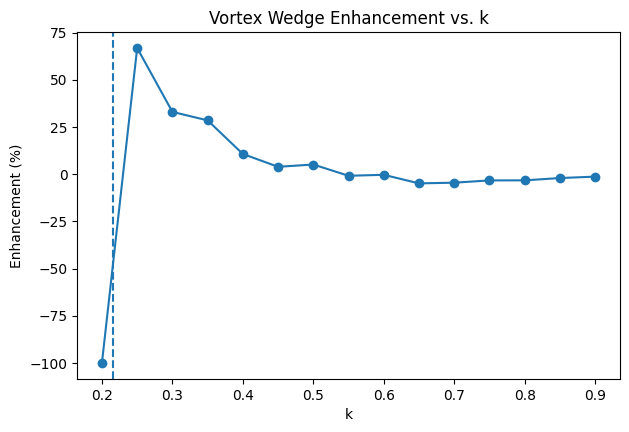

In [7]:

# Compute enhancement curve for diagnostic plotting
enh_curve = [enhancement_for_k(ns, is_prime_arr, float(k), alpha) for k in k_grid]

plt.figure(figsize=(7,4.5))
plt.plot(k_grid, enh_curve, marker='o')
plt.axvline(optimal_k, linestyle='--')
plt.xlabel("k")
plt.ylabel("Enhancement (%)")
plt.title("Vortex Wedge Enhancement vs. k")
plt.show()



## Interpretation Notes

- **Precision**: within-wedge prime fraction; **Recall**: wedge capture rate of all primes up to `N`.
- **Enhancement (%)** compares wedge precision to overall prime density. Positive values indicate enrichment.
- **Bootstrap CI** characterizes variability across resampled index sets (with replacement). Seeded RNG ensures reproducibility.
- **Scaling**: Increase `N` after validating a small run. The vectorized sieve avoids per-number primality calls.
- **Production tie-in** (optional): Mirror the wedge predicate into the C prefilter and log candidates/metrics here.
